# SLML 2026 — Week 1 Environment Smoke Test

Run every cell **top-to-bottom from a clean kernel**: use **Kernel → Restart Kernel and Run All Cells**.

- Each section prints **✓ OK** when the check passes.
- The summary table cell prints the status of all checks.
- The final cell shows an actual plot as a visual confirmation everything works.
- If a cell shows **✗ FAIL**, see the troubleshooting section in `setup.md`.

> **This is a check, not a tutorial.** Every package tested here is used in at least one of Weeks 2–13.

In [1]:
# ── Cell 1: Python version + shared utilities ─────────────────────────────
import sys

# Results tracker — every check cell appends to this list.
# Do NOT edit; the final cell uses it to print the summary table.
_smoke_results = []

def _ver(version_str):
    """Convert '1.26.4' → (1, 26, 4) for tuple comparison."""
    parts = []
    for x in str(version_str).split('.')[:3]:
        try:
            parts.append(int(x))
        except ValueError:
            parts.append(0)
    return tuple(parts)

def _record(label, passed, detail=''):
    status = 'PASS' if passed else f'FAIL  {detail}'
    _smoke_results.append((label, status))
    icon = '✓' if passed else '✗'
    print(f'  {icon}  {label}: {status}')

# ── Python version ─────────────────────────────────────────────────────────
v = sys.version_info
py_ver = f'{v.major}.{v.minor}.{v.micro}'
print(f'Python {sys.version}\n')
ok = v >= (3, 10)
_record('Python >= 3.10', ok,
        f'got {py_ver}; recreate the slml env following setup.md')
if not ok:
    print('  STOP: Python too old. Follow setup.md to recreate the environment.')

Python 3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:17:41) [MSC v.1944 64 bit (AMD64)]

  ✓  Python >= 3.10: PASS


In [2]:
# ── Cell 2: numpy · pandas · scipy ────────────────────────────────────────
# Used every week; scipy.special (Wk 3), scipy.linalg (Wk 8 solution).

_label = 'numpy / pandas / scipy'
try:
    import numpy as np
    import pandas as pd
    import scipy
    import scipy.stats
    import scipy.special
    import scipy.linalg

    # Version checks
    assert _ver(np.__version__) >= (1, 24), \
        f'numpy {np.__version__} < 1.24'
    assert _ver(pd.__version__) >= (2, 0), \
        f'pandas {pd.__version__} < 2.0'
    assert _ver(scipy.__version__) >= (1, 10), \
        f'scipy {scipy.__version__} < 1.10'

    # Functional checks
    rng = np.random.default_rng(42)
    arr = rng.standard_normal((3, 4))
    assert arr.shape == (3, 4)

    df = pd.DataFrame({'x': [1, 2, 3], 'y': [4.0, 5.0, 6.0]})
    assert df.dtypes['y'] == float

    rv = scipy.stats.multivariate_normal(mean=[0, 0], cov=np.eye(2))
    assert rv.pdf([0, 0]) > 0

    b = scipy.special.comb(5, 2)   # Week 3: combinatorics
    assert int(b) == 10

    A = np.array([[2.0, 1.0], [1.0, 3.0]])
    x = scipy.linalg.solve(A, np.array([1.0, 2.0]))  # Week 8 solution
    assert x.shape == (2,)

    print(f'  numpy   {np.__version__}')
    print(f'  pandas  {pd.__version__}')
    print(f'  scipy   {scipy.__version__}')
    _record(_label, True)

except AssertionError as e:
    _record(_label, False, str(e))
except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')

  numpy   1.26.4
  pandas  3.0.5
  scipy   1.17.1
  ✓  numpy / pandas / scipy: PASS


In [3]:
# ── Cell 3: matplotlib (2D · 3D · animation · new cmap API) ───────────────
# plt.get_cmap() tests the CURRENT API; plt.cm.get_cmap() is removed in 3.11.
# FuncAnimation + to_html5_video() requires ffmpeg (Weeks 4–5).
# mpl_toolkits.mplot3d is used in Weeks 5 and 8.

_label = 'matplotlib (2D + 3D + animation)'
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from matplotlib.animation import FuncAnimation
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    assert _ver(matplotlib.__version__) >= (3, 7), \
        f'matplotlib {matplotlib.__version__} < 3.7'

    # 2D scatter
    fig, ax = plt.subplots()
    ax.scatter([1, 2, 3], [4, 5, 6])
    plt.close(fig)

    # New cmap API — plt.get_cmap (NOT the deprecated plt.cm.get_cmap)
    cmap = plt.get_cmap('rainbow')
    assert cmap is not None

    # 3D plot (Weeks 5, 8)
    fig3d = plt.figure()
    ax3d = fig3d.add_subplot(111, projection='3d')
    ax3d.scatter([1], [2], [3])
    plt.close(fig3d)

    # FuncAnimation + ffmpeg writer (Weeks 4, 5)
    fig_anim, ax_anim = plt.subplots()
    line, = ax_anim.plot([], [])
    ax_anim.set_xlim(0, 5)
    ax_anim.set_ylim(0, 5)

    def _init():
        line.set_data([], [])
        return (line,)

    def _animate(i):
        line.set_data([0, i], [0, i])
        return (line,)

    anim = FuncAnimation(fig_anim, _animate, init_func=_init,
                         frames=5, interval=100)
    _ = anim.to_html5_video()  # raises RuntimeError if ffmpeg is not on PATH
    plt.close(fig_anim)

    print(f'  matplotlib {matplotlib.__version__}')
    _record(_label, True)

except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')
    try:
        plt.close('all')
    except Exception:
        pass

  matplotlib 3.9.4
  ✓  matplotlib (2D + 3D + animation): PASS


In [4]:
# ── Cell 4: seaborn ───────────────────────────────────────────────────────
# set_theme() is the current API; sns.set() is deprecated since seaborn 0.12.

_label = 'seaborn >= 0.12'
try:
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    assert _ver(sns.__version__) >= (0, 12), \
        f'seaborn {sns.__version__} < 0.12'

    sns.set_theme(style='whitegrid')   # current API (not deprecated sns.set())
    sns.set_palette('bright')

    # Tiny plot to verify rendering pipeline
    fig, ax = plt.subplots(figsize=(3, 2))
    data = np.random.default_rng(42).standard_normal(20)
    ax.plot(data)
    plt.close(fig)

    print(f'  seaborn {sns.__version__}')
    _record(_label, True)

except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')
    try:
        plt.close('all')
    except Exception:
        pass

  seaborn 0.13.2
  ✓  seaborn >= 0.12: PASS


In [5]:
# ── Cell 5: Pillow ────────────────────────────────────────────────────────
# Used in this test notebook; transitively required by torchvision (Wks 10–11).
# Pillow is now listed explicitly in environment.yml to avoid surprise.

_label = 'Pillow >= 9.0'
try:
    from PIL import Image
    import PIL
    import numpy as np
    from IPython.display import display

    assert _ver(PIL.__version__) >= (9, 0), \
        f'Pillow {PIL.__version__} < 9.0'

    arr = np.random.default_rng(42).integers(0, 256, (8, 8, 3), dtype=np.uint8)
    img = Image.fromarray(arr)
    assert img.size == (8, 8)

    display(img)   # shows the tiny image inline in the notebook

    print(f'  Pillow {PIL.__version__}')
    _record(_label, True)

except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')

  Pillow 12.3.0
  ✓  Pillow >= 9.0: PASS


In [6]:
# ── Cell 6: scikit-learn ──────────────────────────────────────────────────
# Covers all sub-modules used in Weeks 4–9, 13:
#   PCA (Wks 5, 7–9, 13), SVC (Wk 13),
#   AdaBoostClassifier + DecisionTreeClassifier (Wk 9),
#   load_iris (Wks 4–5), load_digits (Wks 7–9, 13).
#   LogisticRegression is a general health check only (Week 7 implements
#   logistic regression from scratch).

_label = 'scikit-learn >= 1.2'
try:
    import sklearn
    from sklearn import datasets
    from sklearn.decomposition import PCA
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import AdaBoostClassifier

    assert _ver(sklearn.__version__) >= (1, 2), \
        f'scikit-learn {sklearn.__version__} < 1.2'

    _SEED = 0

    # load_iris + PCA (Weeks 4–5, 7–8)
    iris = datasets.load_iris()
    pca = PCA(n_components=2, random_state=_SEED)
    X2d = pca.fit_transform(iris.data)
    assert X2d.shape == (150, 2)

    # SVC (Week 13)
    svc = SVC(kernel='rbf', C=1.0, random_state=_SEED)
    svc.fit(X2d, iris.target)
    assert svc.score(X2d, iris.target) > 0.8

    # LogisticRegression (Week 7)
    lr = LogisticRegression(max_iter=200, random_state=_SEED)
    lr.fit(X2d, iris.target)
    assert lr.score(X2d, iris.target) > 0.7

    # load_digits + AdaBoost (Week 9)
    digits = datasets.load_digits(n_class=2)
    dt = DecisionTreeClassifier(max_depth=1, random_state=_SEED)
    dt.fit(digits.data, digits.target)
    ab = AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1, random_state=_SEED),
        n_estimators=3, random_state=_SEED
    )
    ab.fit(digits.data, digits.target)
    assert ab.score(digits.data, digits.target) > 0.8

    print(f'  scikit-learn {sklearn.__version__}')
    _record(_label, True)

except AssertionError as e:
    _record(_label, False, str(e))
except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')

  scikit-learn 1.9.0
  ✓  scikit-learn >= 1.2: PASS


In [7]:
# ── Cell 7: PyTorch ───────────────────────────────────────────────────────
# Covers all torch sub-modules used in Weeks 10–11:
#   nn (MLP, CNN), Conv2d, AvgPool2d, ConvTranspose2d, Upsample,
#   SGD optimiser, random_split, DataLoader.

_label = 'torch >= 2.0'
try:
    import torch
    import torch.nn as nn
    from torch.optim import SGD
    from torch.utils.data import DataLoader, TensorDataset, random_split
    from torch.nn import (Conv2d, AvgPool2d, Linear, Sequential,
                          ConvTranspose2d, Upsample)

    # Strip local build tags like '+cpu' or '+cu121' before version comparison
    _torch_ver = torch.__version__.split('+')[0]
    assert _ver(_torch_ver) >= (2, 0), \
        f'torch {torch.__version__} < 2.0'

    torch.manual_seed(42)

    # Basic tensor op
    x = torch.rand(4, 4)
    y = torch.matmul(x, x.T)
    assert y.shape == (4, 4)

    # Tiny MLP — forward + backward pass (Week 10)
    mlp = nn.Sequential(
        nn.Linear(4, 8), nn.ReLU(),
        nn.Linear(8, 2)
    )
    optimizer = SGD(mlp.parameters(), lr=0.01)
    out = mlp(torch.rand(3, 4))
    loss = out.sum()
    loss.backward()
    optimizer.step()
    assert out.shape == (3, 2)

    # CNN modules (Week 11: LeNet-5, autoencoder)
    cnn = Sequential(
        Conv2d(1, 4, kernel_size=3, padding=1),
        nn.ReLU(),
        AvgPool2d(2),
        ConvTranspose2d(4, 1, kernel_size=2, stride=2)
    )
    dummy = torch.rand(1, 1, 8, 8)
    out_cnn = cnn(dummy)
    assert out_cnn.shape == (1, 1, 8, 8)

    # random_split + DataLoader (Week 11)
    ds = TensorDataset(torch.rand(20, 4), torch.randint(0, 2, (20,)))
    train_ds, val_ds = random_split(
        ds, [16, 4], generator=torch.Generator().manual_seed(42)
    )
    assert len(train_ds) == 16
    loader = DataLoader(train_ds, batch_size=4)
    assert len(loader) == 4

    # Device report (informational — CPU is sufficient for this course)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device_info = 'MPS (Apple Silicon GPU)'
    elif torch.cuda.is_available():
        device_info = f'CUDA — {torch.cuda.get_device_name(0)}'
    else:
        device_info = 'CPU only (sufficient for this course)'

    print(f'  torch {torch.__version__}  |  device: {device_info}')
    _record(_label, True)

except AssertionError as e:
    _record(_label, False, str(e))
except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')

  torch 2.13.0  |  device: CUDA — NVIDIA RTX 4500 Ada Generation
  ✓  torch >= 2.0: PASS


In [8]:
# ── Cell 8: torchvision imports ───────────────────────────────────────────
# Checks that torchvision and its key sub-modules are importable.

_label = 'torchvision >= 0.15'
try:
    import torchvision
    from torchvision import datasets, transforms
    from torchvision.datasets import MNIST as _MNIST          # Week 10, 11
    from torchvision.transforms import Compose, ToTensor, Normalize

    _tv_ver = torchvision.__version__.split('+')[0]
    assert _ver(_tv_ver) >= (0, 15), \
        f'torchvision {torchvision.__version__} < 0.15'

    print(f'  torchvision {torchvision.__version__}')
    _record(_label, True)

except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')

  torchvision 0.28.0
  ✓  torchvision >= 0.15: PASS


In [9]:
# ── Cell 9: MNIST pre-download (optional, ~60 MB, requires internet) ──────
#
# This pre-fetches the dataset used in Weeks 10 and 11 so you are not
# surprised by a network download mid-exercise.
#
# Data is saved to  ../data/  (= Exercises/data/), the same path the
# Week 10 and 11 notebooks use, so the cached data will be reused automatically.
#
# Set SKIP_DOWNLOAD = True if you are currently offline or behind a
# restrictive firewall. Remember to re-run this cell before Week 10.

SKIP_DOWNLOAD = False

if not SKIP_DOWNLOAD:
    import os
    from torchvision import datasets, transforms

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    data_dir = '../data'   # same relative path used by Weeks 10 and 11
    os.makedirs(data_dir, exist_ok=True)
    print(f'Downloading MNIST to: {os.path.abspath(data_dir)}')
    print('(~60 MB total; first run only — subsequent runs use the cached files)')

    try:
        train_data = datasets.MNIST(data_dir, train=True,  download=True,
                                    transform=transform)
        test_data  = datasets.MNIST(data_dir, train=False, download=True,
                                    transform=transform)
        print(f'  MNIST train: {len(train_data)} samples  |  '
              f'test: {len(test_data)} samples')
        _smoke_results.append(('MNIST download', 'PASS'))
        print('MNIST download  ✓ OK')
    except Exception as e:
        msg = str(e)
        _smoke_results.append(('MNIST download', f'FAIL  {msg}'))
        print(f'  ✗  MNIST download FAILED: {msg}')
        print('  Weeks 10 and 11 need this data.')
        print('  Re-run this cell when you have internet access, or see the')
        print('  "MNIST download fails" section in setup.md.')
else:
    _smoke_results.append(('MNIST download', 'SKIPPED (SKIP_DOWNLOAD=True)'))
    print('MNIST download skipped (SKIP_DOWNLOAD=True).')
    print('Re-run this cell with SKIP_DOWNLOAD=False before Week 10.')

(~60 MB total; first run only — subsequent runs use the cached files)
  MNIST train: 60000 samples  |  test: 10000 samples
MNIST download  ✓ OK


## Week 12 — California Housing dataset

The Week 12 exercise (`exercise-12.ipynb`) uses the California Housing dataset,
loaded via `sklearn.datasets.fetch_california_housing` (no external HTTP needed;
data is cached locally by scikit-learn on first run, ~500 KB).
The cell below verifies the dataset is accessible.

In [10]:
# ── Cell 11: Week 12 dataset (California Housing) ────────────────────────

_label = 'Week 12 dataset (California Housing)'
try:
    from sklearn.datasets import fetch_california_housing
    cal = fetch_california_housing()
    assert cal.data.shape == (20640, 8), f'Unexpected shape: {cal.data.shape}'
    assert cal.target.shape == (20640,), f'Unexpected target shape: {cal.target.shape}'
    print(f'  California Housing: {cal.data.shape[0]} samples, '
          f'{cal.data.shape[1]} features')
    _record(_label, True)
except Exception as e:
    _record(_label, False, f'{type(e).__name__}: {e}')


  California Housing: 20640 samples, 8 features
  ✓  Week 12 dataset (California Housing): PASS


In [11]:
# ── Cell 12: IPython.display ──────────────────────────────────────────────
# Used in Weeks 4 and 5 to embed animations inline.

_label = 'IPython.display'
try:
    from IPython.display import HTML, display
    display(HTML(
        '<span style="color:green;font-weight:bold">'  # check bold green text appears
        'IPython.display check — you should see this in bold green.</span>'
    ))
    _smoke_results.append((_label, 'PASS'))
    print('IPython.display  ✓ OK')
except Exception as e:
    _smoke_results.append((_label, f'FAIL  {type(e).__name__}: {e}'))
    print(f'  ✗  IPython.display FAILED: {e}')

IPython.display  ✓ OK


In [12]:
# ── Cell 13: Summary table ────────────────────────────────────────────────
# Prints the status of every check. PASS = ready; FAIL = follow setup.md.

print()
print('=' * 62)
print('  SLML 2026 — Smoke-test summary')
print('=' * 62)
print(f"  {'Check':<36} {'Status'}")
print(f"  {'-'*36} {'-'*22}")

all_pass = True
for label, status in _smoke_results:
    if status == 'PASS':
        icon = '✓'
    elif status.startswith('SKIPPED'):
        icon = '~'
    else:
        icon = '✗'
        all_pass = False
    print(f'  {icon}  {label:<34} {status}')

print('=' * 62)
if all_pass:
    print('  All checks passed — environment is ready for Weeks 2–13.')
else:
    print('  One or more checks FAILED.')
    print('  See the Troubleshooting section in setup.md.')
print('=' * 62)


  SLML 2026 — Smoke-test summary
  Check                                Status
  ------------------------------------ ----------------------
  ✓  Python >= 3.10                     PASS
  ✓  numpy / pandas / scipy             PASS
  ✓  matplotlib (2D + 3D + animation)   PASS
  ✓  seaborn >= 0.12                    PASS
  ✓  Pillow >= 9.0                      PASS
  ✓  scikit-learn >= 1.2                PASS
  ✓  torch >= 2.0                       PASS
  ✓  torchvision >= 0.15                PASS
  ✓  MNIST download                     PASS
  ✓  Week 12 dataset (California Housing) PASS
  ✓  IPython.display                    PASS
  All checks passed — environment is ready for Weeks 2–13.


## Visual confirmation

Every check above closes its plot immediately, so nothing appears on screen even when everything passes. Run the cell below for an actual visual confirmation that your setup works.

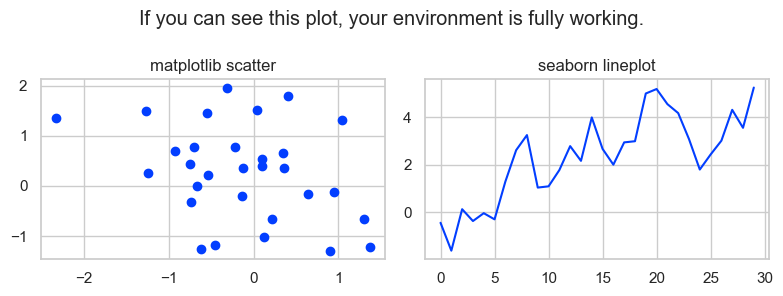

In [13]:
# ── Cell 14: Visual confirmation ──────────────────────────────────────────
# np, plt, sns are already imported and working — checked in Cells 2 and 4.

if all_pass:
    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].scatter(rng.standard_normal(30), rng.standard_normal(30))
    axes[0].set_title('matplotlib scatter')

    sns.lineplot(x=np.arange(30), y=rng.standard_normal(30).cumsum(), ax=axes[1])
    axes[1].set_title('seaborn lineplot')

    fig.suptitle('If you can see this plot, your environment is fully working.')
    fig.tight_layout()
    plt.show()